<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/%20MONTES_DE_OCA-ANDRES-DL-TP1-Co25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires - FIUBA - LSE
# Aprendizaje Profundo - TP1
# Cohorte 24 - 2do bimestre 2026

Este primer TP comienza la semana de la clase 2 y la ventana de entrega estará abierta hasta las **23:59 hs del jueves 21 de mayo (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP1 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local. Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/dMmn8VEJmvRmYgvi6)**. Tanto los resultados, tablas, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el mismo notebook.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL ÚNICO MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP1.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP1-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **PREGUNTA 1** (Temas de la clase 1 y 2)

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola conexión sináptica:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros a optimizar.

<br>

Si bien es cierto, en estos experimentos buscamos tan solo comparar optimizadores (GD vs Adam), de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`, `ini=-5, fin=5`, `ini=-10, fin=10`, etc. Queda a elección de ustedes.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal, polinómica de grado mayor o igual a 3, o la combinación de varias de estas (recomendado). Pero sean prudentes en la elección de la función no lineal, ya que recuerden que es una red de una sola conexión, por ende tampoco elijan algo tan complejo que al final provoque que el modelo no pueda converger.

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para los 3 learning rates. Las 3 gráficas deben estar en el mismo plot para que la comparación visual sea más fácil.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Funciones Aux
def tanh(z):
    return np.tanh(z)

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def grad_mse_tanh(x, y_true, w, b):
    z = w * x + b
    y_pred = tanh(z)
    error = y_pred - y_true

    # Derivada de la activación tanh
    dtanh = 1 - y_pred**2

    # Gradientes vectorizados sobre el full batch
    dw = np.mean(2 * error * dtanh * x)
    db = np.mean(2 * error * dtanh)
    return dw, db, y_pred

In [2]:
# Construcción del Dataset Sintético
np.random.seed(1515)
m = 1000
x = np.linspace(-10, 10, m)

# Mapeo sigmoidal y ruido gaussiano
ruido = np.random.normal(loc=0.0, scale=0.05, size=m)
y = 1 / (1 + np.exp(-x)) + ruido

# Setup
epochs = 100
learning_rates = [0.1, 0.01, 0.001]
w_init, b_init = np.random.randn(), np.random.randn()

# Proceso
historial_costos = {}

for lr in learning_rates:
    w, b = w_init, b_init
    costos = []

    for _ in range(epochs):
        dw, db, y_pred = grad_mse_tanh(x, y, w, b)
        costos.append(mse_loss(y, y_pred))
        w -= lr * dw
        b -= lr * db

    historial_costos[lr] = costos

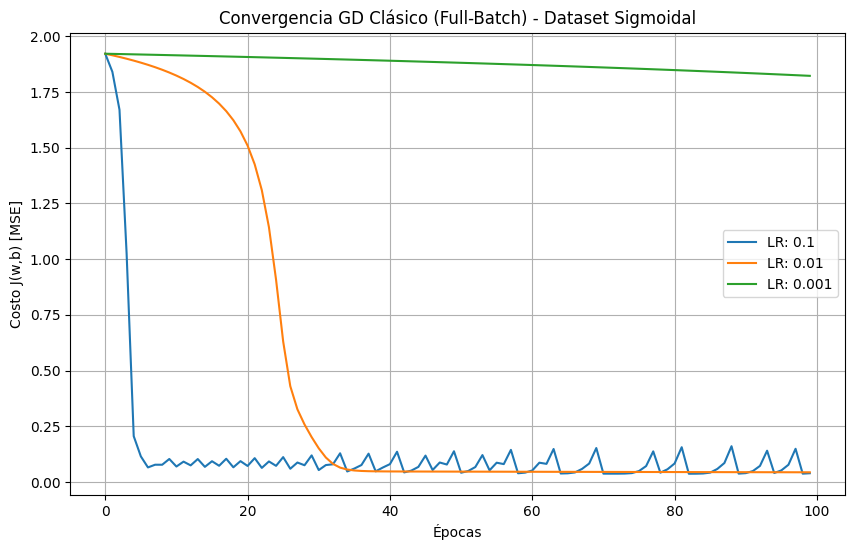

In [3]:
# Plot
plt.figure(figsize=(10, 6))
for lr, costos in historial_costos.items():
    plt.plot(range(epochs), costos, label=f'LR: {lr}')

plt.xlabel('Épocas')
plt.ylabel('Costo J(w,b) [MSE]')
plt.title('Convergencia GD Clásico (Full-Batch) - Dataset Sigmoidal')
plt.legend()
plt.grid(True)
plt.show()

- Se observa como con un LR muy pequeno, tarda demasiado en converger
- En cambio, con un LR muy grande, se converge rapido pero mucho mas inestable
- Y con un LR medio, se ve como demora mas en converger, pero la misma es mucho mas suave y estable

### 1b) Implementación de Adam (2 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno sin mini-batch (full-batch) y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [6]:
# Adam Full-Batch
batch_size = 128
beta1, beta2, epsilon = 0.9, 0.999, 1e-8

historial_costos_adam_full = {lr: [] for lr in learning_rates}

for lr in learning_rates:

    w_f, b_f = w_init, b_init # Mismos valores usados antes
    m_w, v_w, m_b, v_b = 0.0, 0.0, 0.0, 0.0

    for t in range(1, epochs + 1):
        dw, db, y_pred = grad_mse_tanh(x, y, w_f, b_f)
        historial_costos_adam_full[lr].append(mse_loss(y, y_pred))

        # Propagación de estimadores de 1er y 2do momento con corrección de sesgo (W)
        m_w = beta1 * m_w + (1 - beta1) * dw
        v_w = beta2 * v_w + (1 - beta2) * (dw**2)
        w_f -= lr * (m_w / (1 - beta1**t)) / (np.sqrt(v_w / (1 - beta2**t)) + epsilon)

        # Propagación de estimadores de 1er y 2do momento con corrección de sesgo (B)
        m_b = beta1 * m_b + (1 - beta1) * db
        v_b = beta2 * v_b + (1 - beta2) * (db**2)
        b_f -= lr * (m_b / (1 - beta1**t)) / (np.sqrt(v_b / (1 - beta2**t)) + epsilon)


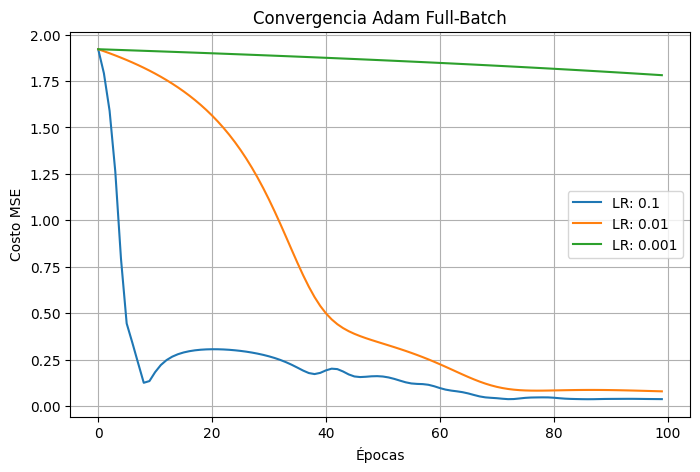

In [7]:
# Plot

plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(range(epochs), historial_costos_adam_full[lr], label=f'LR: {lr}')
plt.xlabel('Épocas')
plt.ylabel('Costo MSE')
plt.title('Convergencia Adam Full-Batch')
plt.legend()
plt.grid(True)

* A diferencia del Descenso de Gradiente clasico, con un LR grande se logra estabilizar
* Hay un rebote inicial, pero los momentos del optimizador amortiguan el salto y lo llevan a convergencia

In [4]:
# Adam Mini-Batch


historial_costos_adam_mini = {}

for lr in learning_rates:
    w_m, b_m = w_init, b_init # Mismos valores usados antes

    # Inicialización nula de estimadores de momento
    m_w, v_w, m_b, v_b = 0.0, 0.0, 0.0, 0.0
    t_m = 1
    costos = []

    for epoch in range(epochs):

        indices = np.random.permutation(m)
        x_shuf, y_shuf = x[indices], y[indices]

        for i in range(0, m, batch_size):
            # Extracción asimétrica de tensores de lote
            x_b = x_shuf[i:i + batch_size]
            y_b = y_shuf[i:i + batch_size]

            # Aproximación del gradiente sobre el sub-tensor X_b
            dw, db, _ = grad_mse_tanh(x_b, y_b, w_m, b_m)

            # Estimadores de momento y corrección de sesgo adaptativo (Tensor W)
            m_w = beta1 * m_w + (1 - beta1) * dw
            v_w = beta2 * v_w + (1 - beta2) * (dw**2)
            m_w_hat = m_w / (1 - beta1**t_m)
            v_w_hat = v_w / (1 - beta2**t_m)
            w_m -= lr * m_w_hat / (np.sqrt(v_w_hat) + epsilon)

            # Estimadores de momento y corrección de sesgo adaptativo (Escalar B)
            m_b = beta1 * m_b + (1 - beta1) * db
            v_b = beta2 * v_b + (1 - beta2) * (db**2)
            m_b_hat = m_b / (1 - beta1**t_m)
            v_b_hat = v_b / (1 - beta2**t_m)
            b_m -= lr * m_b_hat / (np.sqrt(v_b_hat) + epsilon)

            t_m += 1

        # Evaluación del costo global sobre la matriz X completa tras iterar los n/b lotes
        _, _, y_pred_full = grad_mse_tanh(x, y, w_m, b_m)
        costos.append(mse_loss(y, y_pred_full))

    historial_costos_adam_mini[lr] = costos

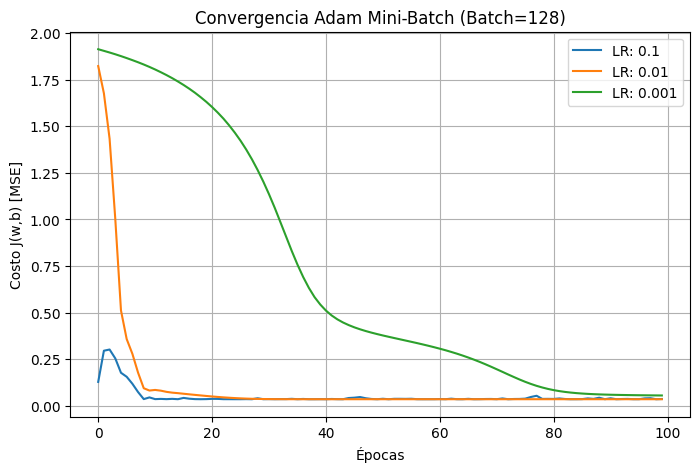

In [5]:
# Plot
plt.figure(figsize=(8, 5))
for lr, costos in historial_costos_adam_mini.items():
    plt.plot(range(epochs), costos, label=f'LR: {lr}')

plt.xlabel('Épocas')
plt.ylabel('Costo J(w,b) [MSE]')
plt.title(f'Convergencia Adam Mini-Batch (Batch={batch_size})')
plt.legend()
plt.grid(True)
plt.show()

* Al actualizar los pesos por cada lote (y no al final de toda la epoca), el tiempo de convergencia se reduce para todos los LRs
* Esto permite converger utilizando LRs pequenos, a diferencia de los metodos anteruires

### 1c) Comparativa de optimizadores (0.5 puntos)  
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas. Deben haber 3 plots o 3 subplots, uno para cada learning rate.
- Graficar el dataset original sintético (y(x)) y compararlo con la función hallada por el modelo, para ver si efectivamente el modelo logró deducir un patrón no lineal parecido al patrón no lineal escogido para el dataset. Hacerlo para cada optimizador y cada learning rate en un plot grande de 9 subplots.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes.

### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate, el que consideres que se nota mejor la diferencia.
- Las 3 trayectorias deben estar en la misma superficie 3D y empezar en el mismo punto.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico. También si desean pueden hacer que el gráfico sea animado usando `matplotlib.animation` y `IPython.display`.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia.

### **RECOMENDACIÓN**:

Voy a valorar mucho que sus análisis, explicaciones y conclusiones sean bastante detalladas y con coherencia en los resultados obtenidos. Donde se evidencie un análisis propio de un humano estudiante de posgrado y no solo copiar y pegar lo que te dijo ChatGPT. Llevo ya años con esto, así que me daré cuenta rapidamente cuando sea así y cuando no.

Les recomiendo revisar el notebook sobre optimizadores que se encuentra en el repo. Pueden acceder mediante el siguiente [enlace](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/blob/ap_2026/CLASE%202/Notebooks/clase2_4_optimizadores.ipynb). En ese notebook vemos cómo aplicar GD y Adam full-batch para una red con relación lineal. Les servirá mucho como guía para realizar esta pregunta. Ahí también podrán ver cómo se hace una animación de un gráfico 3D.

Además, de igual forma tienen disponible el siguiente [material adicional del repo](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/tree/ap_2026/CLASE%202/Teoria/Material%20adicional), el cual le servirá para aplicar Adam, ya no solo en su versión full-batch, sino también en mini-batch

# **PREGUNTA 2** (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

**Descarga del dataset:**  
El conjunto de datos puede descargarse en el siguiente [enlace](https://drive.google.com/file/d/1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ/view?usp=sharing)

---

## Descripción general:

El dataset recopila información sobre las compras realizadas por distintos clientes en una tienda durante el último año.  
Cada registro representa una transacción e incluye datos tanto del cliente como del producto adquirido.

---

## El dataset contiene la siguiente información:

- **User_ID:** Código identificador único del cliente que efectuó la compra.  
- **Product_ID:** Código identificador único del producto adquirido.  
- **Age:** Rango de edad del cliente.  
- **Gender:** Género del cliente (F: Femenino, M: Masculino).  
- **Marital_Status:** Estado civil del cliente (0: Soltero, 1: Casado).  
- **City_Category:** Tipo de zona donde se encuentra la sucursal donde se realizó la compra.  
  - A: Barrio de clase alta  
  - B: Barrio de clase media  
  - C: Barrio de clase media-baja  
- **Stay_In_Current_City_Years:** Número de años que el cliente ha venido comprando en la tienda desde su primera visita.  
- **Product_Category:** Categoría del producto comprado.  
- **Product_Subcategory_1:** Subcategoría principal del producto.  
- **Product_Subcategory_2:** Subcategoría secundaria del producto.  
- **Purchase:** Monto pagado por el producto en esa transacción.

---

## Objetivo del caso de estudio:

Desarrollar un **modelo predictivo** capaz de estimar el **gasto promedio** que realizará un cliente, a partir de su información demográfica y sus patrones de compra. Tener en cuenta que se busca que el modelo prediga el gasto promedio por cliente, no el gasto en cada nueva transacción individual.


### 2a) EDA y preparación del dataset (2 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar detalladamente los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente. **Tener mucho cuidado con el data leakage**.



Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada. Cada justificación se debe redactar a detalle y sustentar con gráficas y/o tablas.


### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

### 2c) Evaluación del Modelo (1 punto)
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteracion utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de por lo menos 0.70 para el set de validation.

### 2d) Conclusiones finales (0.5 puntos)
Redactar de manera detallada las conclusiones finales y si se cumplió con el objetivo o no.